# 🤖 AI Forecasting Arena: Multi-Agent Competition

> **Welcome to the AI Forecasting Arena!** In this notebook, we pit multiple AI agents against each other in a head-to-head time series forecasting competition. Each agent will autonomously develop, test, and refine its own forecasting solution to predict 6 weeks of weekly sales data.

## 🎯 The Challenge

Can AI agents autonomously create state-of-the-art forecasting models? We're about to find out!

**The Mission:** Build autonomous AI agents capable of:
- 🧠 **Self-Coding**: Generate Python forecasting code from scratch
- 🔧 **Self-Debugging**: Detect and fix errors automatically
- 🏆 **Competing**: Produce the most accurate 6-week sales forecasts

**The Tools:**
- **DeepAgents Framework**: Autonomous agent orchestration
- **Nixtla Ecosystem**: MLForecast, StatsForecast, NeuralForecast
- **Foundation Models**: Amazon Chronos-2 for zero-shot forecasting
- **LLM Models**: Claude, GPT, Gemini (head-to-head comparison)


Let the games begin! 🎮


---

## 📥 Part 1: Data Preparation - Setting the Battlefield

Before our AI agents can compete, we need to prepare the arena. We're working with **weekly sales data** from multiple stores and products—a complex multi-time series forecasting challenge.

**What we're loading:**
- 📊 **Sales data**: Historical weekly sales across stores and products
- 📦 **Stock availability**: Binary indicator of product availability
- 📋 **Master data**: Store and product metadata for enrichment


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

# Define index columns
INDEX = ["Store", "Product"]

# Load the data
print("📥 Loading data files...")
sales = pd.read_csv("data/Sales.csv").set_index(INDEX)
in_stock = pd.read_csv("data/Stock_availability.csv").set_index(INDEX)
master = pd.read_csv("data/Master.csv").set_index(INDEX)

# Convert date columns to datetime
sales.columns = pd.to_datetime(sales.columns)
in_stock.columns = pd.to_datetime(in_stock.columns)

print(f"✅ Data loaded: {sales.shape[0]} Store-Product combinations × {sales.shape[1]} time periods")
print(f"📊 Challenge scope: {sales.shape[0]:,} unique time series to forecast!")

📥 Loading data files...
✅ Data loaded: 599 Store-Product combinations × 159 time periods
📊 Challenge scope: 599 unique time series to forecast!


### 🔄 Step 1.1: Data Transformation to Tidy Format

Time series forecasting libraries love **tidy data** (long format). We'll transform our wide-format data and enrich it with metadata.

**Transformation pipeline:**
1. Melt from wide → long format (one row per store-product-date)
2. Merge stock availability data
3. Join master data (store/product attributes)
4. Create unique identifiers for each time series


In [ ]:
print("🔄 Transforming to tidy format...")

full_df = (
    sales.reset_index()
    .melt(
        id_vars=['Store', 'Product'],
        var_name='ds',  # 'ds' = date stamp (standard for Nixtla libraries)
        value_name='y'  # 'y' = target variable (standard for Nixtla libraries)
    )
    .merge(
        in_stock.reset_index().melt(
            id_vars=['Store', 'Product'],
            var_name='ds',
            value_name='in_stock'
        ),
        on=['Store', 'Product', 'ds'],
        how='left',
    )
    .merge(
        master.reset_index(),
        on=['Store', 'Product'],
        how='left'
    )
    .assign(
       unique_id=lambda x: x['Store'].astype(str) + '_' + x['Product'].astype(str)
    )
)

print(f"✅ Tidy dataframe created: {len(full_df):,} rows")
print(f"📈 Time series per Store-Product combination: {full_df['unique_id'].nunique():,}")
full_df.head()

🔄 Transforming to tidy format...
✅ Tidy dataframe created: 95,241 rows
📈 Time series per Store-Product combination: 599


,Store,Product,ds,y,in_stock,ProductGroup,Division,Department,DepartmentGroup,StoreFormat,Format,unique_id
0,0,126,2021-04-12 00:00:00,0.0,True,301202,3012,30,11,1,13,0_126
1,0,182,2021-04-12 00:00:00,0.0,False,440403,4404,44,11,1,13,0_182
2,1,124,2021-04-12 00:00:00,13.0,True,240201,2402,24,11,1,13,1_124
3,2,124,2021-04-12 00:00:00,5.0,True,240201,2402,24,11,1,13,2_124
4,2,126,2021-04-12 00:00:00,0.0,False,301202,3012,30,11,1,13,2_126


### ✂️ Step 1.2: Train/Test Split - The Competition Rules

To evaluate our agents fairly, we hold out the **last 6 weeks** of data as our test set. This simulates a real-world scenario where agents must forecast into the unknown future.

**Competition Rules:**
- 🎓 **Training data**: All historical data up to cutoff date
- 🎯 **Test data**: Last 6 weeks (held secret from agents)
- 📏 **Forecast horizon**: 6 weeks ahead
- ✅ **Success metric**: Lowest MASE (Mean Absolute Scaled Error)


In [ ]:
# Train/test split: last 6 weeks held out for evaluation
cutoff_date = full_df['ds'].max() - pd.Timedelta(weeks=6)

df_long_train = full_df[full_df['ds'] <= cutoff_date].copy()
df_long_test = full_df[full_df['ds'] > cutoff_date].copy()

print("═" * 70)
print("📅 TRAIN/TEST SPLIT SUMMARY")
print("═" * 70)
print(f"⏱️  Cutoff date: {cutoff_date.date()}")
print(f"📚 Training set: {len(df_long_train):,} observations")
print(f"   └─ Period: {df_long_train['ds'].min().date()} → {df_long_train['ds'].max().date()}")
print(f"🎯 Test set: {len(df_long_test):,} observations (agents must predict this!)")
print(f"   └─ Period: {df_long_test['ds'].min().date()} → {df_long_test['ds'].max().date()}")
print(f"🔢 Total time series: {df_long_train['unique_id'].nunique():,}")
print("═" * 70)

df_long_train.head()

══════════════════════════════════════════════════════════════════════
📅 TRAIN/TEST SPLIT SUMMARY
══════════════════════════════════════════════════════════════════════
⏱️  Cutoff date: 2024-03-11
📚 Training set: 91,647 observations
   └─ Period: 2021-04-12 → 2024-03-11
🎯 Test set: 3,594 observations (agents must predict this!)
   └─ Period: 2024-03-18 → 2024-04-22
🔢 Total time series: 599
══════════════════════════════════════════════════════════════════════


,Store,Product,ds,y,in_stock,ProductGroup,Division,Department,DepartmentGroup,StoreFormat,Format,unique_id
0,0,126,2021-04-12 00:00:00,0.0,True,301202,3012,30,11,1,13,0_126
1,0,182,2021-04-12 00:00:00,0.0,False,440403,4404,44,11,1,13,0_182
2,1,124,2021-04-12 00:00:00,13.0,True,240201,2402,24,11,1,13,1_124
3,2,124,2021-04-12 00:00:00,5.0,True,240201,2402,24,11,1,13,2_124
4,2,126,2021-04-12 00:00:00,0.0,False,301202,3012,30,11,1,13,2_126


### 💾 Step 1.3: Export Training Data

Save the training data to `train.csv` - this is the **only data** our AI agents will see. They must work with this file to create their forecasting solutions.


In [ ]:
df_long_train.to_csv("train.csv", index=False)
print("✅ Training data exported to train.csv")
print(f"📁 File size: {len(df_long_train):,} rows × {len(df_long_train.columns)} columns")
print("🔒 Test data remains hidden - agents must forecast the unknown!")

✅ Training data exported to train.csv
📁 File size: 91,647 rows × 12 columns
🔒 Test data remains hidden - agents must forecast the unknown!


---

## ⚙️ Part 2: Agent Configuration - Creating Our AI Competitors

Now the exciting part begins! We'll create **autonomous AI agents** that will compete to build the best forecasting model. Each agent is powered by a different LLM (Claude, GPT, Gemini) and given the same tools and mission.

### 🛠️ Agent Capabilities

Each agent is equipped with:

- 🧰 **Tools**:
  - `write_python_script()` - Generate forecasting code
  - `run_python_script()` - Execute and test their code
- 💾 **Memory**: MemorySaver for state management (agents remember their progress)
- 📁 **Workspace**: Filesystem backend for code persistence
- 🎯 **Mission**: Detailed system prompt with forecasting best practices

### 🏗️ Architecture

Built on **DeepAgents** (LangChain-based framework):
- Agents iterate autonomously (plan → write → test → debug → repeat)
- Self-correction capabilities when errors occur
- Access to cutting-edge forecasting libraries (Nixtla ecosystem, Chronos-2)

!["deep Agent"](deep_agent.png)

Let's configure our competitors! 🏁

In [ ]:
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver
import uuid
import subprocess
import os

# ============================================
# CONFIGURATION
# ============================================

PROJECT_DIR = os.getcwd()
AGENTS_NAMES = ["claude-sonnet-4-5-20250929", "google_genai:gemini-2.5-pro","gpt-5-mini","gpt-5" ]  # Competing models

checkpointer = MemorySaver()

# ============================================
# AGENT TOOLS
# ============================================

def run_python_script(path: str) -> str:
    """
    Execute a Python script and return stdout/stderr.

    Args:
        path: Path to the Python script to execute

    Returns:
        str: Script output or error message
    """
    try:
        result = subprocess.run(
            ["python", path],
            capture_output=True,
            text=True,
            timeout=300  # 5-minute timeout
        )
        if result.returncode == 0:
            return result.stdout or "✅ Script executed successfully"
        else:
            return f"❌ Error:\n{result.stderr}"
    except subprocess.TimeoutExpired:
        return "⏱️ Timeout: script took too long (> 5 min)"
    except Exception as e:
        return f"💥 Exception: {str(e)}"


def write_python_script(path: str, code: str) -> str:
    """
    Write a Python script to the project directory.

    Args:
        path: File name (will be created in PROJECT_DIR)
        code: Python source code to write

    Returns:
        str: Confirmation or error message
    """
    try:
        full_path = os.path.join(PROJECT_DIR, os.path.basename(path))
        with open(full_path, "w", encoding="utf-8") as f:
            f.write(code)
        return f"✅ File created: {full_path}"
    except Exception as e:
        return f"❌ Error: {str(e)}"


# ============================================
# OPTIMIZED SYSTEM PROMPT
# ============================================

SYSTEM_PROMPT = """You are an expert Data Scientist specializing in time series forecasting with Nixtla libraries (MLForecast, StatsForecast, NeuralForecast) and the chronos-2 foundation model.

🎯 MISSION
Create a high-performance forecasting model for 6-week ahead weekly sales predictions ("W-MON" frequency).

📦 ENVIRONMENT
- All dependencies are installed (pandas, numpy, nixtla, scikit-learn, lightgbm)
- You can use the Chronos-2 foundation model with CPU. Here's example code:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cpu")
# Energy price forecasting configuration
target = "target"  # Column name containing the values to forecast (energy prices)
prediction_length = 24  # Number of hours to forecast ahead
id_column = "id"  # Column identifying different time series (countries/regions)
timestamp_column = "timestamp"  # Column containing datetime information
timeseries_id = "DE"  # Specific time series to visualize (Germany)

# Load historical energy prices and past values of covariates
energy_context_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet"
)
display(energy_context_df.head())

# Load future values of covariates
energy_test_df = pd.read_parquet(
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet"
)
energy_future_df = energy_test_df.drop(columns=target)
# Generate predictions with covariates
energy_pred_df = pipeline.predict_df(
    energy_context_df,
    future_df=energy_future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
)
- Input file: train.csv
  • Columns: unique_id, ds ("W-MON"), y, in_stock, Store, Product, etc.
  • Format: weekly data in long (tidy) format
- Output format: forecast_{model_name}.csv in {PROJECT_DIR}
  • Required columns: unique_id, ds, y
  • One row per prediction (Store × Product × 6 weeks)

🏆 COMPETITIVE OBJECTIVE
- Minimize MASE (Mean Absolute Scaled Error)
- Minimize RMSE (Root Mean Squared Error)
- Use advanced techniques to maximize accuracy

⚙️ TECHNICAL CONSTRAINTS
1. **Data Display**: Show ONLY .head(), .info(), .describe() - NEVER full data
2. **Errors**: Focus only on the last line of tracebacks
3. **Code Quality**: Clean, commented Python (PEP 8) with error handling
4. **Naming Convention**:
   - Code → works_{model_name}.py
   - Forecasts → forecast_{model_name}.csv
5. **Iterative Workflow**: Write → Save → Execute → Debug → Repeat
6. **Output Format**: CSV with exactly 3 columns (unique_id, ds, y) in {PROJECT_DIR}

💡 STRATEGIC RECOMMENDATIONS
1. **Exploration**:
   - Analyze seasonality, trends, outliers
   - Check missing values and in_stock variable
   - Descriptive statistics per Store/Product

2. **Feature Engineering**:
   - Use in_stock as exogenous variable
   - Create temporal features (week, month, lags)
   - Encode categorical variables (Store, Product)

3. **Modeling**:
   - Test multiple models
   - Time series cross-validation
   - Ensembles for robustness (model averaging)

4. **Optimization**:
   - Handle series with sparse data
   - Treat outliers and extreme values

🚀 RECOMMENDED APPROACH
1. Load and explore train.csv quickly (.head(), .info())
2. Analyze patterns (seasonality, trends)
3. Choose appropriate model(s)
4. Develop iteratively (test, debug, refine)
5. Generate forecasts in required format
6. Validate output CSV structure in {PROJECT_DIR}

⚠️ CRITICAL REQUIREMENTS
- Focus on forecast quality (MASE, RMSE)
- Handle ALL Store × Product combinations
- Ensure final CSV is complete and correct in {PROJECT_DIR}
- Comment code to explain choices and write an approach summary in summary_{model_name}.txt in {PROJECT_DIR}
"""

# ============================================
# 🚀 AGENT EXECUTION - LET THE COMPETITION BEGIN!
# ============================================

print("=" * 70)
print("🤖 AI FORECASTING ARENA - COMPETITION STARTING")
print("=" * 70)
print(f"\n🏁 Competing agents: {', '.join(AGENTS_NAMES)}")
print(f"📊 Training data: train.csv")
print(f"\n⚔️  May the best forecaster win!\n")

for idx, agent_name in enumerate(AGENTS_NAMES, 1):
    print(f"\n{'='*70}")
    print(f"🎯 AGENT {idx}/{len(AGENTS_NAMES)}: {agent_name}")
    print(f"{'='*70}\n")

    try:
        # Create agent
        agent = create_deep_agent(
            model=agent_name,
            backend=FilesystemBackend(root_dir=PROJECT_DIR),
            tools=[run_python_script, write_python_script],
            checkpointer=checkpointer,
            system_prompt=SYSTEM_PROMPT.replace("{model_name}", agent_name)
        )

        # User message
        user_message = f"""Generate a high-performance forecasting model for the data in train.csv in {PROJECT_DIR}:

**Objective**: 6-week ahead forecasts
**Data**: Weekly sales "W-MON" (columns: unique_id, ds, y + features)
**Primary Metric**: MASE
**Secondary Metric**: RMSE
**Output Format**: forecast_{agent_name}.csv (columns: unique_id, ds, y) in {PROJECT_DIR}"""

        # Stream execution
        print(f"🚀 Agent {agent_name} starting...\n")

        for chunk in agent.stream(
            {"messages": [{"role": "user", "content": user_message}]},
            stream_mode="updates",
            config={"configurable": {"thread_id": agent_name  }} ,
        ):
            for step, data in chunk.items():
                if data and "messages" in data:
                    # Simplified display to track progress
                    print(f"  📝 {step}")

        print(f"\n✅ Agent {agent_name} completed successfully!")
        print(f"   📄 Generated code: works_{agent_name}.py")
        print(f"   📊 Forecasts: forecast_{agent_name}.csv")

    except KeyboardInterrupt:
        print(f"\n⏸️ Agent {agent_name} interrupted by user")
        break
    except Exception as e:
        print(f"\n❌ Error with agent {agent_name}:")
        print(f"   {str(e)}")
        continue

print(f"\n{'='*70}")
print("🏁 ALL AGENTS HAVE FINISHED")
print(f"{'='*70}\n")
print("🏆 Next: Performance evaluation - Who will win the forecasting arena?")


🤖 AI FORECASTING ARENA - COMPETITION STARTING

🏁 Competing agents: claude-sonnet-4-5-20250929, google_genai:gemini-2.5-pro, gpt-5-mini, gpt-5
📊 Training data: train.csv

⚔️  May the best forecaster win!


🎯 AGENT 1/4: claude-sonnet-4-5-20250929

🚀 Agent claude-sonnet-4-5-20250929 starting...

  📝 PatchToolCallsMiddleware.before_agent
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model
  📝 tools
  📝 model

✅ Agent claude-sonnet-4-5-20250929 completed successfully!
   📄 Generated code: works_claude-sonnet-4-5-20250929.py
   📊 Forecasts: forecast_claude-sonnet-4-5-20250929.csv



---

## 🏆 Part 3: Performance Showdown - Evaluating the Winners

The moment of truth! Let's see which AI agent built the best forecasting model. We'll evaluate each agent's predictions against the hidden test set using industry-standard metrics.

### 📊 Evaluation Metrics

- **🎯 MASE** (Mean Absolute Scaled Error):  scaled error vs naive baseline
  - MASE < 1.0 = Beats naive forecasting ✅
  - Lower is better
- **📉 RMSE** (Root Mean Squared Error): Penalizes large errors
- **📏 MAE** (Mean Absolute Error): Average absolute error
- **📈 Coverage**: % of required forecasts generated

**Who will claim the forecasting crown?** 👑


GT(_tbl_data=shape: (4, 10)
┌──────┬────────────┬─────────────┬──────────┬───┬─────────────┬──────────┬─────────────┬──────────┐
│ Rank ┆ logo       ┆ Name        ┆ RMSE     ┆ … ┆ MAE_bar     ┆ MASE     ┆ MASE_bar    ┆ Coverage │
│ ---  ┆ ---        ┆ ---         ┆ ---      ┆   ┆ ---         ┆ ---      ┆ ---         ┆ ---      │
│ i64  ┆ str        ┆ str         ┆ f64      ┆   ┆ str         ┆ f64      ┆ str         ┆ f64      │
╞══════╪════════════╪═════════════╪══════════╪═══╪═════════════╪══════════╪═════════════╪══════════╡
│ 1    ┆ claude.png ┆ claude-sonn ┆ 2.971608 ┆ … ┆ <div style= ┆ 0.499839 ┆ <div style= ┆ 100.0    │
│      ┆            ┆ et-4-5-2025 ┆          ┆   ┆ "width:     ┆          ┆ "width:     ┆          │
│      ┆            ┆ 0929        ┆          ┆   ┆ 100px; …    ┆          ┆ 100px; …    ┆          │
│ 2    ┆ openai.png ┆ gpt-5       ┆ 3.132786 ┆ … ┆ <div style= ┆ 0.502023 ┆ <div style= ┆ 100.0    │
│      ┆            ┆             ┆          ┆   ┆ "width:     ┆          ┆ "width:     ┆          │
│      ┆            ┆             ┆          ┆   ┆ 100px; …    ┆          ┆ 100px; …    ┆          │
│ 3    ┆ gemini.png ┆ google_gena ┆ 3.80896  ┆ … ┆ <div style= ┆ 0.527974 ┆ <div style= ┆ 100.0    │
│      ┆            ┆ i:gemini-2. ┆          ┆   ┆ "width:     ┆          ┆ "width:     ┆          │
│      ┆            ┆ 5-pro       ┆          ┆   ┆ 100px; …    ┆          ┆ 100px; …    ┆          │
│ 4    ┆ openai.png ┆ gpt-5-mini  ┆ 3.333217 ┆ … ┆ <div style= ┆ 0.552344 ┆ <div style= ┆ 100.0    │
│      ┆            ┆             ┆          ┆   ┆ "width:     ┆          ┆ "width:     ┆          │
│      ┆            ┆             ┆          ┆   ┆ 100px; …    ┆          ┆ 100px; …    ┆          │
└──────┴────────────┴─────────────┴──────────┴───┴─────────────┴──────────┴─────────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x328df1f90>, _boxhead=Boxhead([ColInfo(var='Rank', type=<ColInfoTypeEnum.stub: 2>, column_label='Rank', column_align='right', column_width=None), ColInfo(var='logo', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='left', column_width=None), ColInfo(var='Name', type=<ColInfoTypeEnum.default: 1>, column_label='Agent', column_align='left', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label='RMSE', column_align='right', column_width=None), ColInfo(var='RMSE_bar', type=<ColInfoTypeEnum.default: 1>, column_label='Performance', column_align='left', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label='MAE', column_align='right', column_width=None), ColInfo(var='MAE_bar', type=<ColInfoTypeEnum.default: 1>, column_label='Performance', column_align='left', column_width=None), ColInfo(var='MASE', type=<ColInfoTypeEnum.default: 1>, column_label='MASE', column_align='right', column_width=None), ColInfo(var='MASE_bar', type=<ColInfoTypeEnum.default: 1>, column_label='Performance', column_align='left', column_width=None), ColInfo(var='Coverage', type=<ColInfoTypeEnum.default: 1>, column_label='Coverage %', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3016dcaf0>, _spanners=Spanners([SpannerInfo(spanner_id='📉 RMSE', spanner_level=0, spanner_label='📉 RMSE', spanner_units=None, spanner_pattern=None, vars=['RMSE', 'RMSE_bar'], built=None), SpannerInfo(spanner_id='📊 MAE', spanner_level=0, spanner_label='📊 MAE', spanner_units=None, spanner_pattern=None, vars=['MAE', 'MAE_bar'], built=None), SpannerInfo(spanner_id='🎯 MASE', spanner_level=0, spanner_label='🎯 MASE', spanner_units=None, spanner_pattern=None, vars=['MASE', 'MASE_bar'], built=None)]), _heading=Heading(title='🏆 AI Forecasting Arena - Final Results', subtitle='Performance comparison on hidden test set', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x32bea6dd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x322239cd0>, _source_notes=[Md(
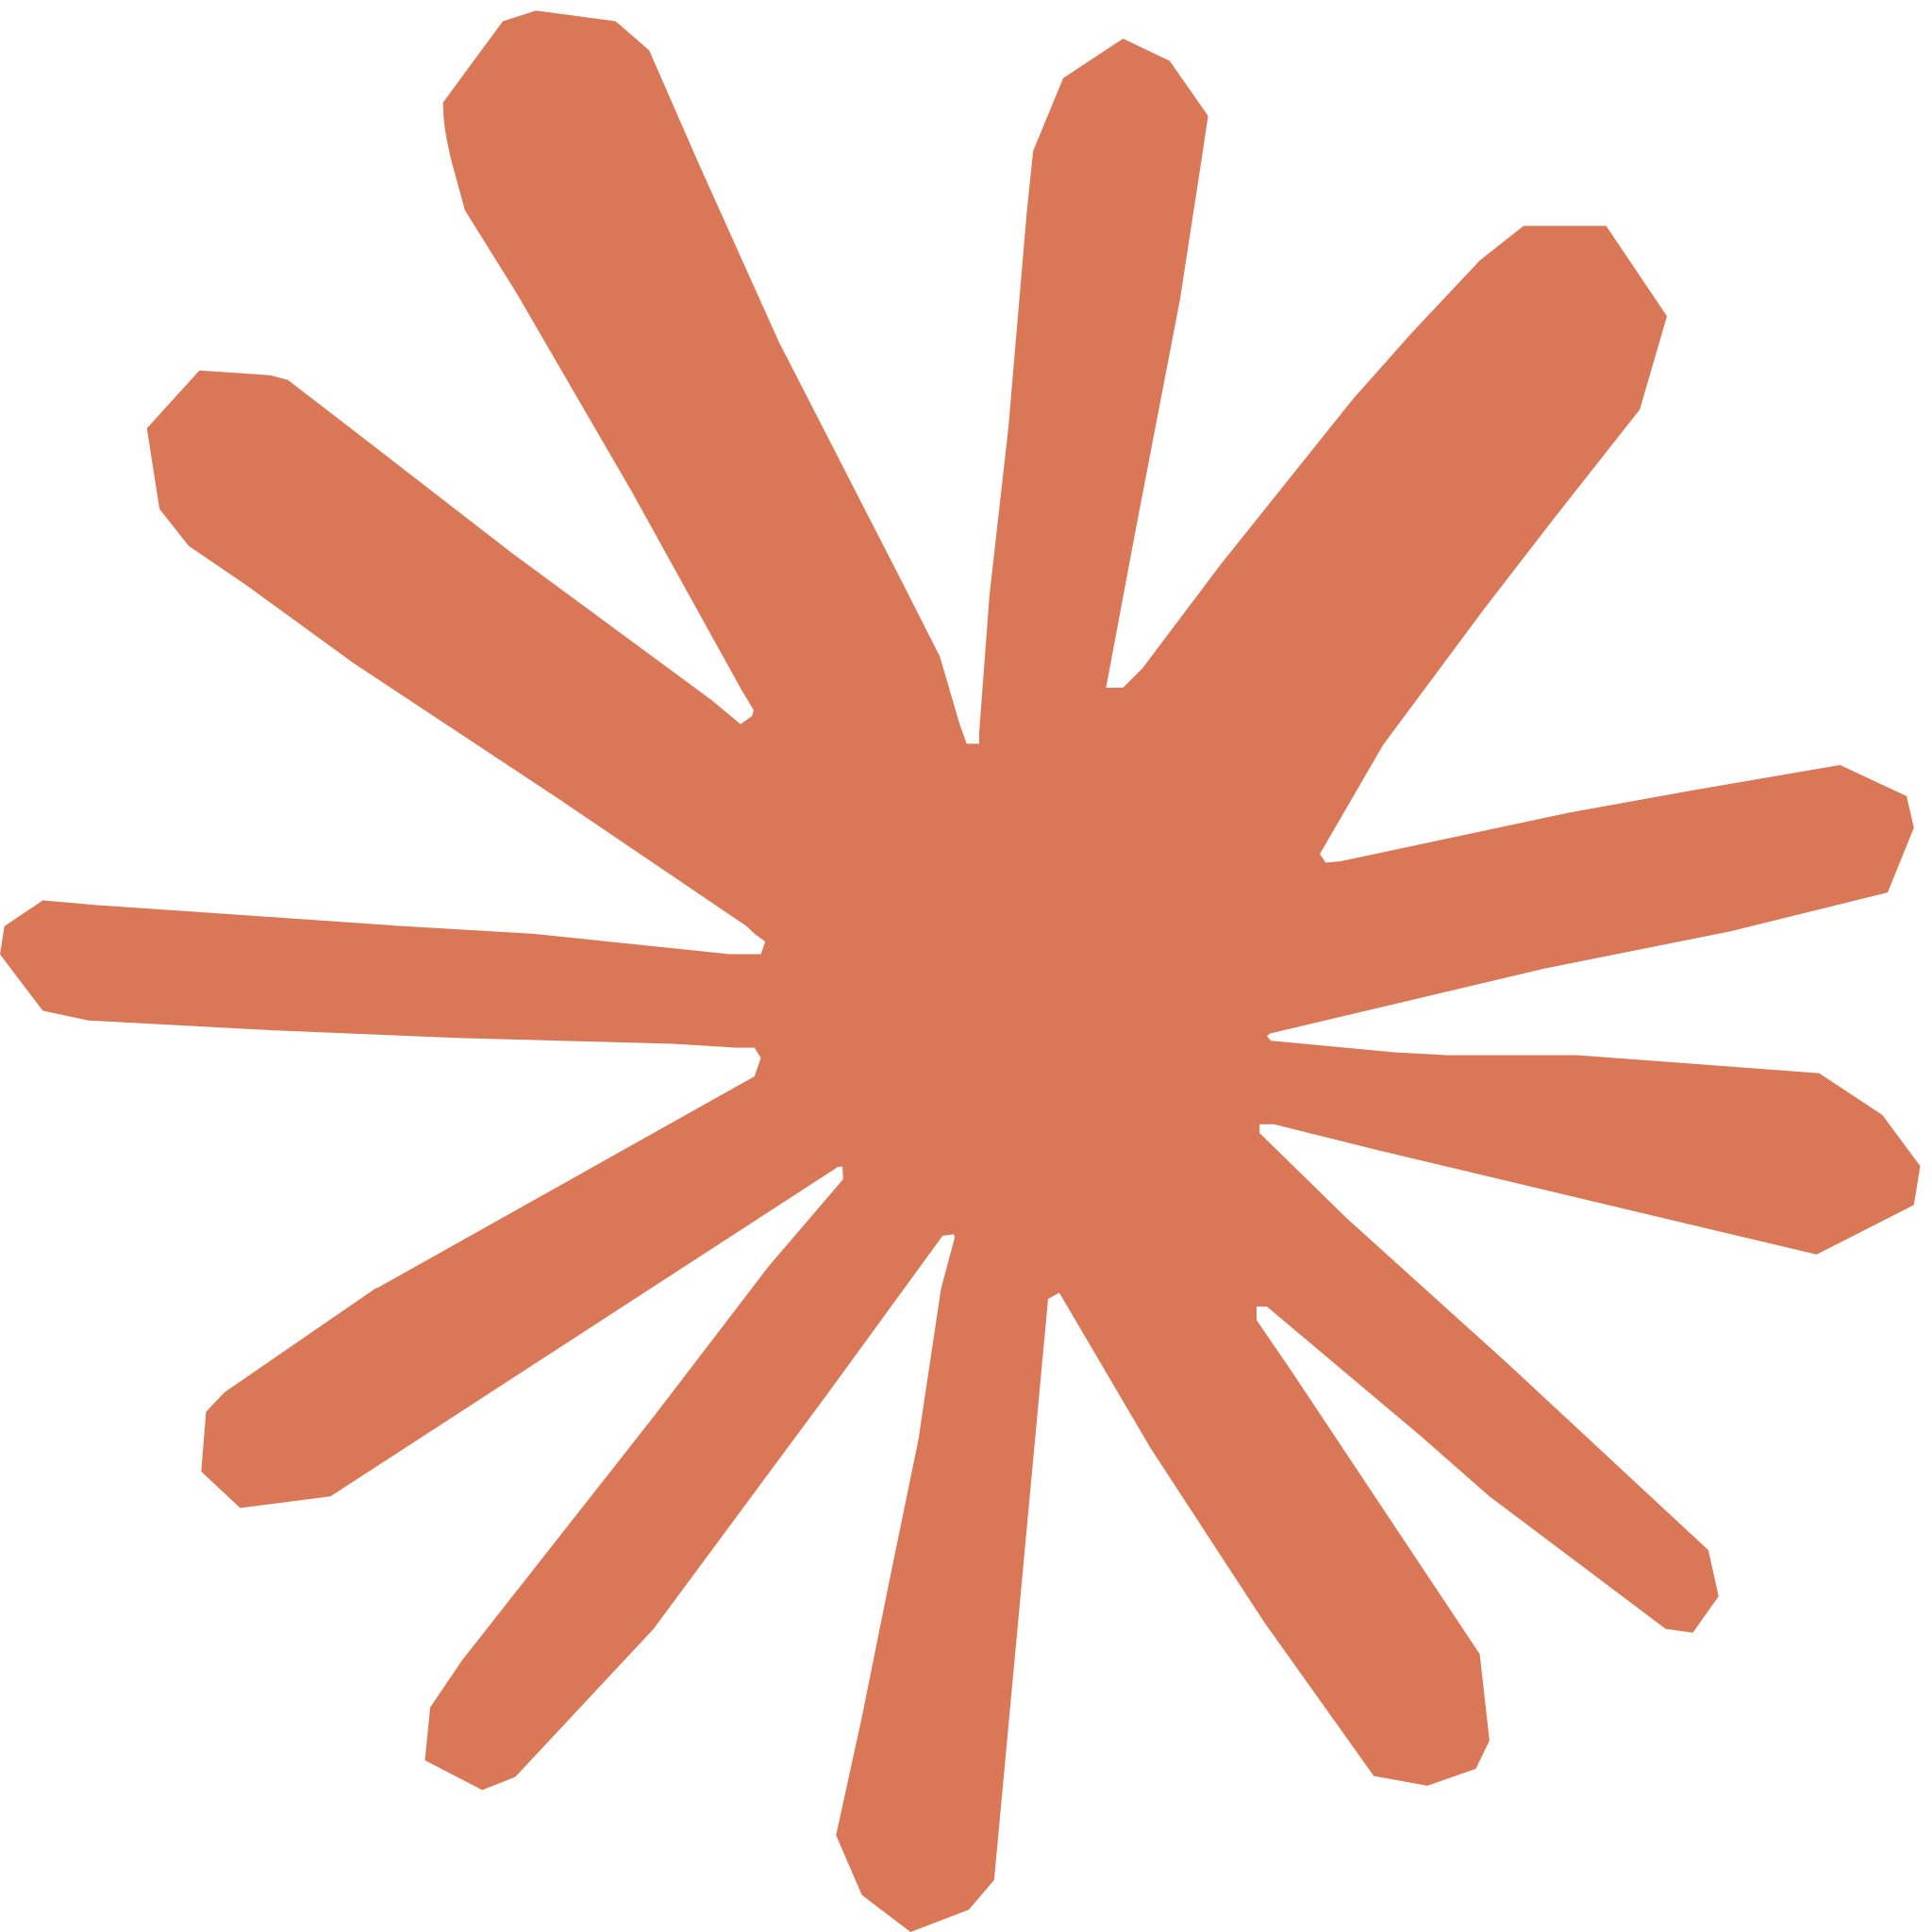
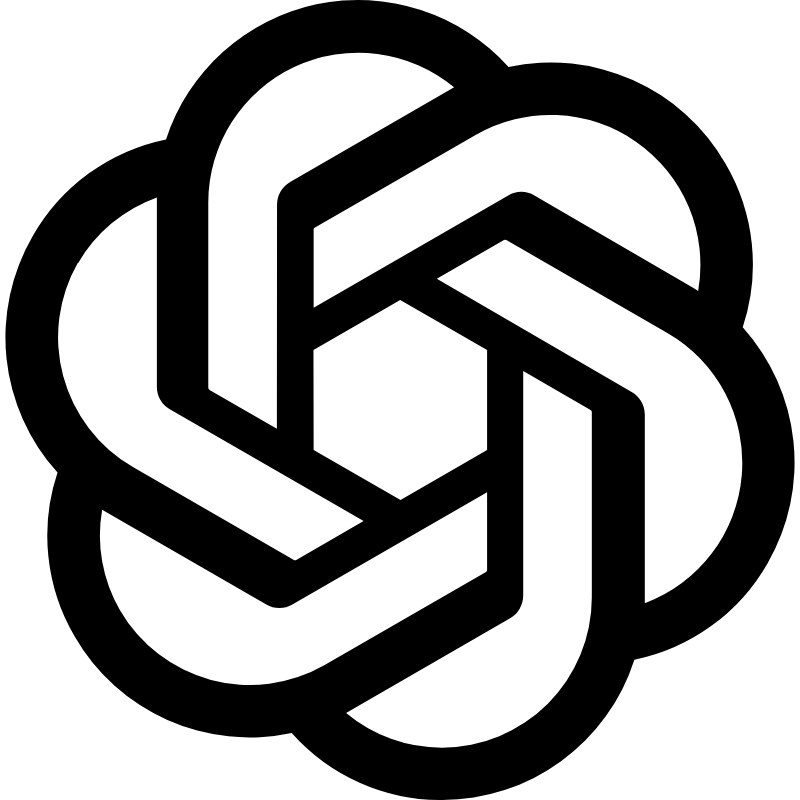
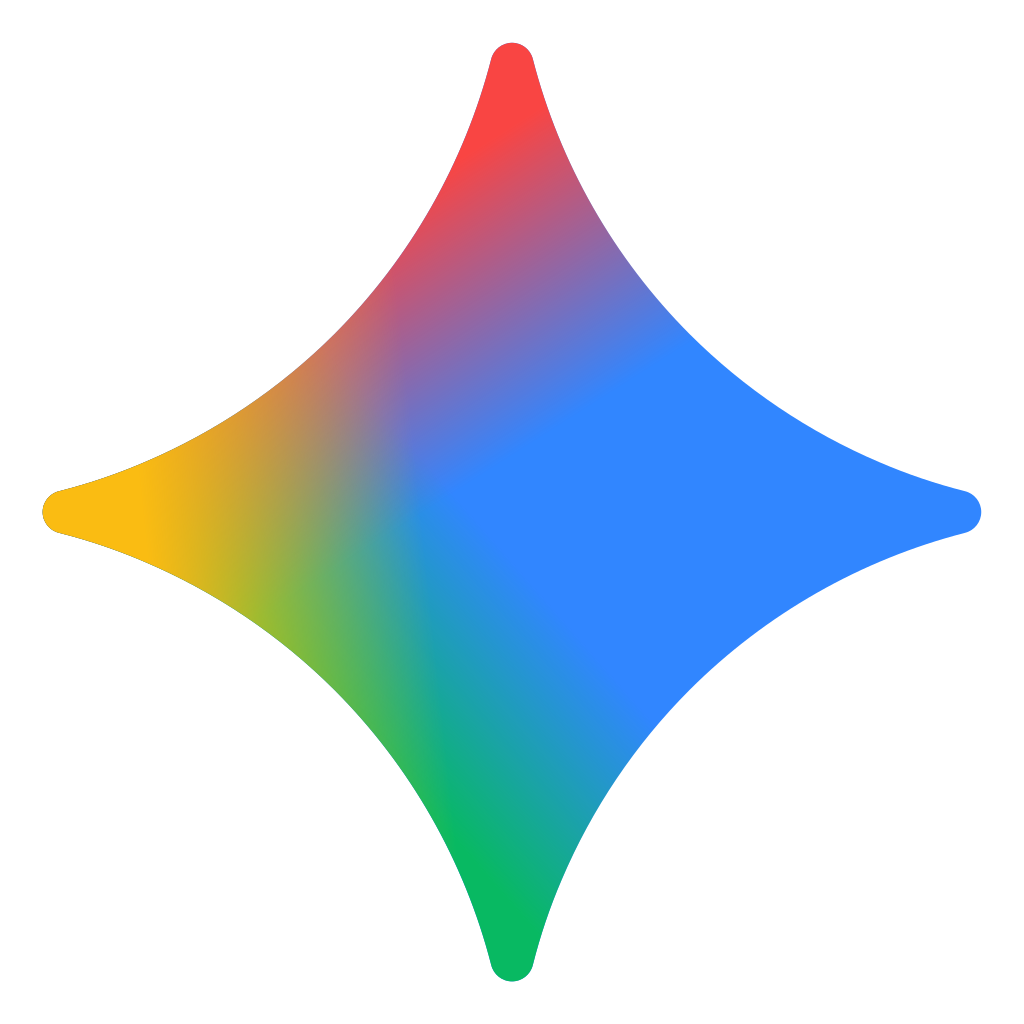
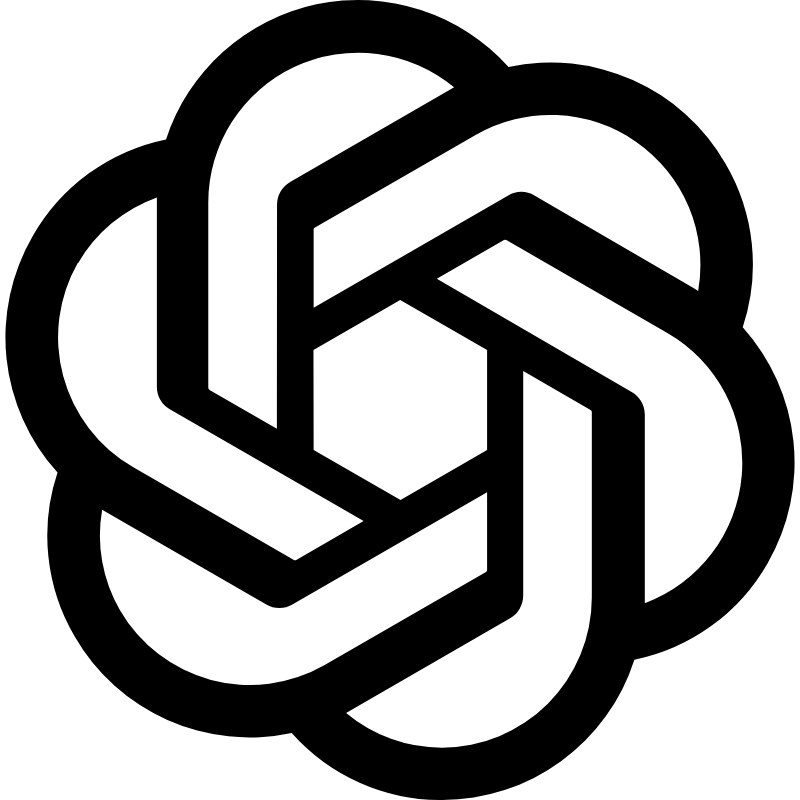

In [ ]:
import glob
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error
import polars as pl
from great_tables import GT, md
import warnings
warnings.filterwarnings('ignore')

# ============================================
# EVALUATION FUNCTIONS
# ============================================

def calculate_simple_mase(y_true, y_pred, y_train):
    """Calculate MASE (Mean Absolute Scaled Error)"""
    try:
        mae_model = np.mean(np.abs(y_true - y_pred))
        naive_forecast = np.full_like(y_true, y_train[-1])
        mae_naive = np.mean(np.abs(y_true - naive_forecast))
        return mae_model / mae_naive if mae_naive != 0 else np.nan
    except:
        return np.nan


def evaluate_single_forecast(forecast_file, test_df, train_df):
    """Evaluate a single agent's forecast file"""
    try:
        agent_name = os.path.basename(forecast_file).replace("forecast_", "").replace(".csv", "")
        forecast_df = pd.read_csv(forecast_file)

        required_cols = ['unique_id', 'ds', 'y']
        if not all(col in forecast_df.columns for col in required_cols):
            print(f"❌ {agent_name}: missing columns")
            return None

        forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
        test_df_copy = test_df.copy()
        test_df_copy['ds'] = pd.to_datetime(test_df_copy['ds'])

        merged = test_df_copy.merge(
            forecast_df,
            on=['unique_id', 'ds'],
            how='inner',
            suffixes=('_true', '_pred')
        )

        if len(merged) == 0:
            print(f"⚠️ {agent_name}: no matching predictions")
            return None

        y_true = merged['y_true'].values
        y_pred = merged['y_pred'].values

        mask = ~(np.isnan(y_true) | np.isnan(y_pred))
        y_true = y_true[mask]
        y_pred = y_pred[mask]

        if len(y_true) == 0:
            print(f"⚠️ {agent_name}: empty data after cleaning")
            return None

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)

        train_series = train_df.groupby('unique_id')['y'].apply(list)
        all_train = np.concatenate([np.array(s) for s in train_series if len(s) > 0])
        mase = calculate_simple_mase(y_true, y_pred, all_train)

        n_expected = len(test_df_copy)
        coverage = (len(merged) / n_expected * 100) if n_expected > 0 else 0

        return {
            'Rank': None,  # will be filled after sorting
            'Name': agent_name,
            'RMSE': rmse,
            'MAE': mae,
            'MASE': mase,
            'Coverage': coverage
        }

    except Exception as e:
        print(f"❌ Error evaluating {agent_name}: {str(e)}")
        return None


# ============================================
# HTML BAR CHART FUNCTION
# ============================================

def create_bar(prop_fill: float, max_width: int = 100, height: int = 20, color: str = "#4CAF50") -> str:
    """Create HTML divs to visualize performance as a bar chart."""
    width = round(max_width * prop_fill, 2)
    px_width = f"{width}px"
    return f"""\
    <div style="width: {max_width}px; background-color: #e0e0e0;">\
        <div style="height:{height}px;width:{px_width};background-color:{color};"></div>\
    </div>\
    """


def get_logo_filename(agent_name: str) -> str:
    """Get logo filename based on agent name"""
    name_lower = agent_name.lower()
    if 'gemini' in name_lower:
        return "gemini.png"
    elif 'gpt' in name_lower or 'openai' in name_lower:
        return "openai.png"
    elif 'claude' in name_lower:
        return "claude.png"
    else:
        return "deep_agent.png"


# ============================================
# EXECUTE EVALUATION WITH GREAT_TABLES
# ============================================

forecast_files = glob.glob(f"{PROJECT_DIR}/forecast_*.csv")

if not forecast_files:
    print("⚠️ No forecast files found!")
    print(f"📁 Searching in: {PROJECT_DIR}")
else:
    # Evaluate each forecast file
    results = []
    for forecast_file in forecast_files:
        result = evaluate_single_forecast(forecast_file, df_long_test, df_long_train)
        if result:
            results.append(result)

    if results:
        # Create pandas DataFrame then convert to polars
        results_pd = pd.DataFrame(results).sort_values('MASE').reset_index(drop=True)
        results_pd['Rank'] = range(1, len(results_pd) + 1)

        # Convert to polars
        df_polars = pl.from_pandas(results_pd)

        # Calculate proportions for bars (inverted because lower = better)
        max_rmse = df_polars['RMSE'].max()
        max_mae = df_polars['MAE'].max()
        max_mase = df_polars['MASE'].max()

        # Add columns with HTML bars and logos
        res = (
            df_polars
            .with_columns([
                # Inverted proportions (1 - normalized) so best performers show 100%
                (1 - pl.col("RMSE") / max_rmse).alias("rmse_prop"),
                (1 - pl.col("MAE") / max_mae).alias("mae_prop"),
                (1 - pl.col("MASE") / max_mase).alias("mase_prop"),
                # Logo filename
                pl.col("Name").map_elements(lambda x: get_logo_filename(x), return_dtype=pl.Utf8).alias("logo"),
            ])
            .with_columns([
                # HTML bars
                pl.col("rmse_prop").map_elements(lambda x: create_bar(x, max_width=100, height=20, color="#2196F3"), return_dtype=pl.Utf8).alias("RMSE_bar"),
                pl.col("mae_prop").map_elements(lambda x: create_bar(x, max_width=100, height=20, color="#FF9800"), return_dtype=pl.Utf8).alias("MAE_bar"),
                pl.col("mase_prop").map_elements(lambda x: create_bar(x, max_width=100, height=20, color="#4CAF50"), return_dtype=pl.Utf8).alias("MASE_bar"),
            ])
            .select(["Rank", "logo", "Name", "RMSE", "RMSE_bar", "MAE", "MAE_bar", "MASE", "MASE_bar", "Coverage"])
        )

        # Create table with great_tables
        gt_table = (
            GT(res, rowname_col="Rank")
            .tab_header(
                title="🏆 AI Forecasting Arena - Final Results",
                subtitle="Performance comparison on hidden test set"
            )
            .cols_label(**{
                "logo": "",
                "Name": "Agent",
                "RMSE": "RMSE",
                "RMSE_bar": "Performance",
                "MAE": "MAE",
                "MAE_bar": "Performance",
                "MASE": "MASE",
                "MASE_bar": "Performance",
                "Coverage": "Coverage %"
            })
            .fmt_image("logo", path="./", height=30)
            .fmt_number(["RMSE", "MAE"], decimals=2)
            .fmt_number(["MASE"], decimals=3)
            .fmt_number(["Coverage"], decimals=1)
            .tab_spanner(label="📉 RMSE", columns=["RMSE", "RMSE_bar"])
            .tab_spanner(label="📊 MAE", columns=["MAE", "MAE_bar"])
            .tab_spanner(label="🎯 MASE", columns=["MASE", "MASE_bar"])
            .tab_source_note(
                md(
                    '<br><div style="text-align: center;">'
                    "🏆 Lower scores = Better performance | "
                    "Bars show relative performance (longer = better)"
                    "</div><br>"
                )
            )
        )

        # Display table
        display(gt_table)

    else:
        print("⚠️ No successful evaluations")

 ## 🎤 let the competitors talks about their approach

In [ ]:

#  show the approach summary of each agent
for agent_name in AGENTS_NAMES:
    print(f"💡 Approach summary for {agent_name}:")
    with open(f"{PROJECT_DIR}/summary_{agent_name}.txt", "r") as f:
        print(f.read())
    print("\n")


💡 Approach summary for claude-sonnet-4-5-20250929:
HIGH-PERFORMANCE FORECASTING MODEL SUMMARY
6-Week Ahead Weekly Sales Predictions

Author: Claude Sonnet 4.5 (20250929)
Date: 2025
Objective: Minimize MASE and RMSE for weekly sales forecasting

1. DATA OVERVIEW

Training Data Characteristics:
- Total observations: 91,647
- Unique time series: 599 (Store × Product combinations)
- Time period: 2021-04-12 to 2024-03-11 (153 weeks)
- Frequency: Weekly (W-MON)
- Target variable: Sales (y)

Key Data Insights:
- 43.1% zero sales (sparse/intermittent demand pattern)
- 88.5% products in stock (important predictive signal)
- Mean sales: 2.96 units
- Median sales: 1.00 units (right-skewed distribution)
- Max sales: 494 units
- No missing values

Available Features:
- Temporal: ds (date, W-MON frequency)
- Target: y (sales)
- Exogenous dynamic: in_stock (availability status)
- Static categorical: Store, Product, ProductGroup, Division, Department,
                      DepartmentGroup, StoreFormat